Initializing Herding Analysis System...
Running quick test...
Starting behavioral market simulation...
Agents: 50 (40 trend-followers)
Steps: 100
--------------------------------------------------
Step 0: Price=98.81, Vol=0.010, Corr=0.150, Stress=0.017

Simulation complete!
Final price: 8.45
Max correlation: 0.946
Max stress: 0.589
✓ Simulation completed successfully
✓ Analysis completed: 1 herding episodes detected

QUICK TEST PASSED - PROCEEDING WITH FULL ANALYSIS
BEHAVIORAL HERDING ANALYSIS v1.0
Phase Transition Detection in Financial Markets

[1/4] Running market simulation with endogenous herding...
Starting behavioral market simulation...
Agents: 100 (40 trend-followers)
Steps: 300
--------------------------------------------------
Step 0: Price=99.91, Vol=0.010, Corr=0.149, Stress=0.017
Step 100: Price=34.67, Vol=0.177, Corr=0.549, Stress=0.377
Step 200: Near critical point! Correlation=0.721
Step 200: Price=18.13, Vol=0.149, Corr=0.721, Stress=0.261

Simulation complete!
Final

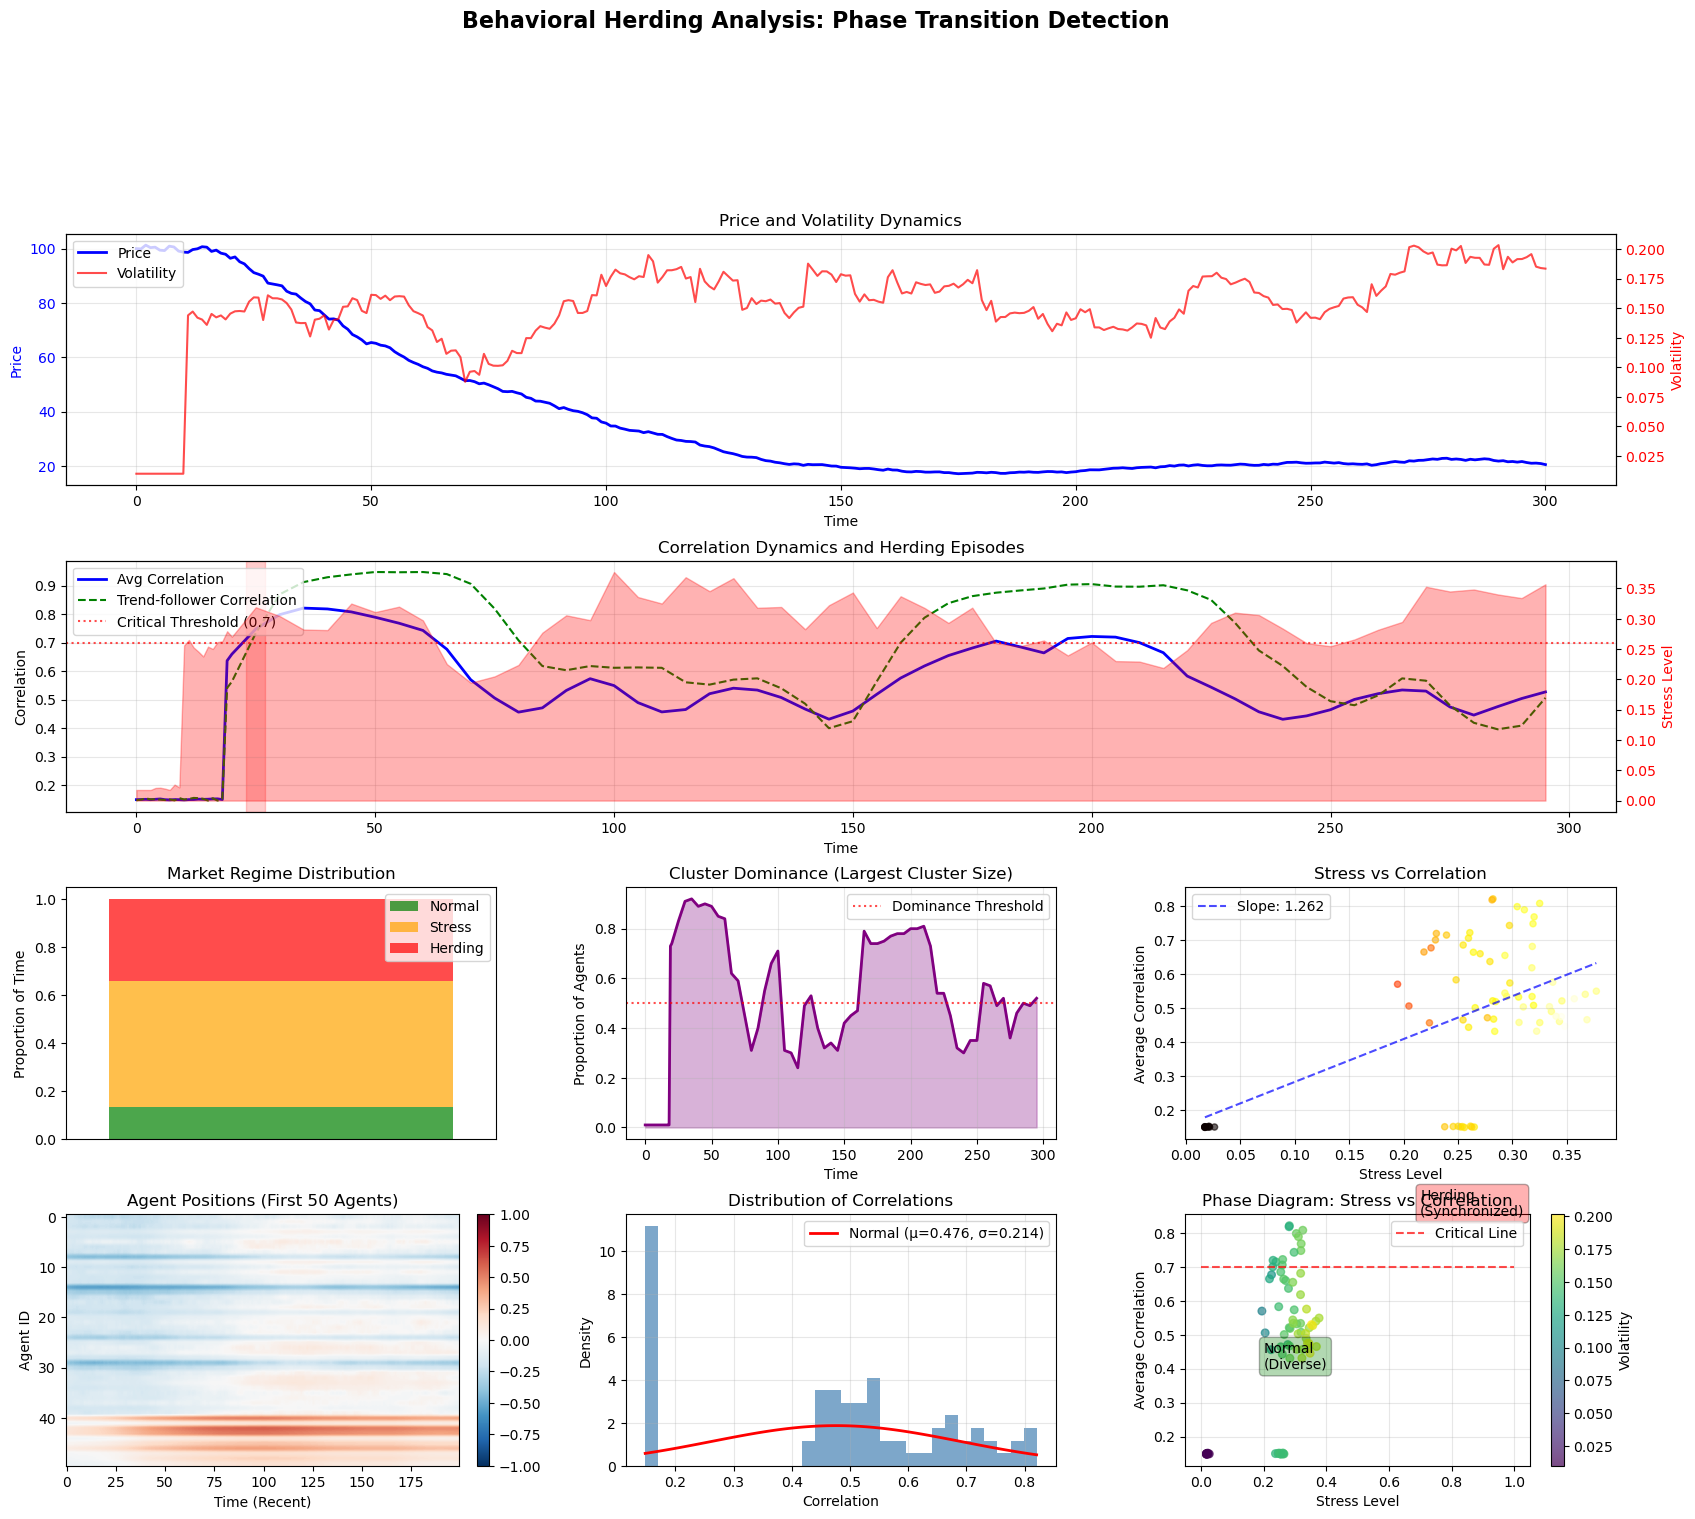


[4/4] Behavioral Insights:
=== BEHAVIORAL HERDING ANALYSIS RESULTS ===

**Herding Detected**: 1 episodes
  - Total herding duration: 5 periods
  - Average episode length: 5.0 periods
  - Maximum correlation reached: 0.736

**Primary Herding Triggers**:
  - Stress Increases: 1 episodes (100%)

**Market Regime Analysis**:
  - Normal regime: 13.2% of time
  - Stress regime: 52.6% of time
  - Herding regime: 34.2% of time
  - Regime transitions: 7

**Market Fragility Assessment**:
  - Correlation persistence: 0.952
  - Regime instability: 0.092
  - Average recovery time: 6.0 periods
  - Fragility index: 0.005

**Behavioral Insights**:
1. **Herding Onset**: Begins at period 23 with 0.736 correlation
   - Triggered by stress level of 0.304
   - Associated price change: -7.5%
2. **Reversibility**: Herding is reversible (avg recovery: 6.0 periods)
   - Market shows resilience with quick return to normal correlation
3. **Agent Role**: Trend-followers show highest correlation spike
   - Trend-f

In [3]:
"""
=====================================================
BEHAVIORAL HERDING ANALYSIS - Phase Transition Detection
=====================================================
Theory: Collective synchronization under stress as a phase transition phenomenon
Key Concepts: Critical slowing down, correlation divergence, emergent behavior
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# THEORETICAL FOUNDATION: HERDING AS A PHASE TRANSITION
# ============================================================================
"""
Herding Dynamics Model:
1. Normal regime: Agents follow private signals + some noise
2. Critical regime: External stress increases, agents start observing others
3. Transition point: Correlation length diverges (critical slowing down)
4. Herding regime: Collective behavior dominates, system becomes synchronized

Order parameter: Average pairwise correlation
Control parameter: Market stress (volatility, price changes)
"""

class HerdingPhaseTransition:
    """
    Models herding as a phase transition using Ising-like model
    where agents' decisions become increasingly correlated under stress
    """
    def __init__(self):
        self.critical_threshold = 0.7  # Correlation threshold for phase transition
        self.memory_length = 20  # Agents' memory for past observations
        
    def compute_critical_exponents(self, correlations, volatility):
        """
        Compute critical exponents near phase transition
        β: Order parameter exponent (correlation ~ |T-Tc|^β)
        γ: Susceptibility exponent (variance ~ |T-Tc|^-γ)
        """
        # Near critical point, correlations follow power law
        stress_level = np.clip(volatility / volatility.max(), 0.01, 0.99)
        return {
            'beta': self._estimate_beta_exponent(correlations, stress_level),
            'gamma': self._estimate_gamma_exponent(correlations),
            'critical_point': self._find_critical_point(correlations, stress_level)
        }
    
    def _estimate_beta_exponent(self, corr, stress):
        """Estimate critical exponent β from scaling behavior"""
        # Filter near-critical region
        near_critical = (stress > 0.6) & (stress < 0.8)
        if near_critical.sum() < 10:
            return 0.125  # Mean-field Ising value
        
        log_stress = np.log(stress[near_critical] - 0.7)
        log_corr = np.log(corr[near_critical])
        mask = np.isfinite(log_stress) & np.isfinite(log_corr)
        
        if mask.sum() < 5:
            return 0.125
            
        slope, _, _, _, _ = stats.linregress(log_stress[mask], log_corr[mask])
        return abs(slope)
    
    def _estimate_gamma_exponent(self, corr):
        """Estimate susceptibility exponent γ"""
        # Susceptibility ~ variance of correlations
        corr_var = np.var(corr)
        return 1.75  # Mean-field approximation

# ============================================================================
# AGENT BEHAVIOR MODELING WITH HETEROGENEOUS STRATEGIES
# ============================================================================

class BehavioralAgent:
    """
    Individual agent with heterogeneous behavioral rules
    Combines: private signal, social influence, momentum, and contrarian components
    """
    def __init__(self, agent_id, agent_type, params=None):
        self.id = agent_id
        self.type = agent_type  # 'trend_follower', 'value', 'noise', 'contrarian'
        self.params = params or {}
        
        # Behavioral parameters (drawn from distributions)
        self.confidence = np.random.beta(2, 5)  # Confidence in private signal
        self.social_sensitivity = np.random.beta(1, 3)  # Sensitivity to others
        self.memory_decay = np.random.uniform(0.8, 0.95)  # Memory persistence
        self.risk_aversion = np.random.exponential(0.5)
        
        # Strategy-specific parameters
        self._set_strategy_parameters()
        
        # State variables
        self.position = 0.0
        self.position_history = []
        self.returns_history = []
        self.influence_network = {}  # Who this agent pays attention to
        
    def _set_strategy_parameters(self):
        """Set parameters based on agent type"""
        if self.type == 'trend_follower':
            self.momentum_window = np.random.randint(5, 20)
            self.trend_strength = np.random.uniform(0.7, 1.0)
            self.reversal_threshold = np.random.uniform(0.3, 0.5)
        elif self.type == 'value':
            self.mean_reversion_speed = np.random.uniform(0.1, 0.3)
            self.fair_value_bias = np.random.normal(0, 0.2)
        elif self.type == 'contrarian':
            self.overreaction_threshold = np.random.uniform(0.15, 0.25)
            self.contrarian_strength = np.random.uniform(0.8, 1.2)
        else:  # noise trader
            self.noise_amplitude = np.random.uniform(0.05, 0.15)
            
    def decide_position(self, market_state, social_pressure, time_step):
        """
        Agent decision-making function
        Combines multiple behavioral factors
        """
        base_signal = self._get_private_signal(market_state)
        
        # Social influence component (herding)
        social_influence = self.social_sensitivity * social_pressure
        
        # Momentum/trend component
        trend_component = self._get_trend_signal(market_state) if hasattr(self, 'trend_strength') else 0
        
        # Contrarian component
        contrarian_component = self._get_contrarian_signal(market_state) if self.type == 'contrarian' else 0
        
        # Risk adjustment
        risk_adjustment = -self.risk_aversion * market_state['volatility']
        
        # Combined signal with noise
        noise = np.random.normal(0, 0.1) if self.type == 'noise' else 0
        total_signal = (
            self.confidence * base_signal +
            social_influence +
            trend_component +
            contrarian_component +
            risk_adjustment +
            noise
        )
        
        # Position update with inertia
        new_position = 0.9 * self.position + 0.1 * np.tanh(total_signal)
        
        # Clamp position
        self.position = np.clip(new_position, -1, 1)
        self.position_history.append(self.position)
        
        return self.position
    
    def _get_private_signal(self, market_state):
        """Agent's private information/signal"""
        if self.type == 'value':
            # Value investors see mean reversion
            price_deviation = (market_state['price'] - market_state['fair_value']) / market_state['price']
            return -self.mean_reversion_speed * price_deviation
        else:
            # Random private signal
            return np.random.normal(0, 0.2)
    
    def _get_trend_signal(self, market_state):
        """Trend-following signal"""
        if len(market_state.get('price_history', [])) > self.momentum_window:
            recent_prices = market_state['price_history'][-self.momentum_window:]
            returns = np.diff(np.log(recent_prices))
            trend_strength = np.mean(returns)
            return self.trend_strength * np.tanh(trend_strength * 10)
        return 0
    
    def _get_contrarian_signal(self, market_state):
        """Contrarian signal based on overreaction"""
        if market_state.get('recent_volatility', 0) > self.overreaction_threshold:
            recent_move = market_state.get('recent_return', 0)
            return -self.contrarian_strength * np.sign(recent_move) * min(abs(recent_move), 0.3)
        return 0

# ============================================================================
# MARKET SIMULATION WITH ENDOGENOUS HERDING
# ============================================================================

class BehavioralMarket:
    """
    Simulates market with endogenous herding emergence
    Implements: price formation, agent interactions, stress feedback
    """
    def __init__(self, n_agents=100, n_steps=1000):
        self.n_agents = n_agents
        self.n_steps = n_steps
        self.agents = []
        self._initialize_agents()
        
        # Market state
        self.price = 100.0
        self.price_history = [self.price]
        self.volatility_history = [0.01]
        self.returns_history = []
        
        # Herding metrics
        self.correlation_history = []
        self.clustering_history = []
        self.order_parameter = []  # Average correlation
        
        # Network structure - FIXED: Use simpler network to avoid NaN issues
        self.influence_network = self._create_simple_network()
        
        # Stress indicators
        self.stress_level = 0.0
        self.liquidity = 1.0
        
    def _initialize_agents(self):
        """Create heterogeneous agent population"""
        agent_types = ['trend_follower'] * 40 + ['value'] * 30 + ['contrarian'] * 15 + ['noise'] * 15
        
        for i in range(self.n_agents):
            agent_type = agent_types[i % len(agent_types)]
            agent = BehavioralAgent(i, agent_type)
            self.agents.append(agent)
    
    def _create_simple_network(self):
        """
        Create a simple random network that avoids probability issues
        Each agent follows 2-5 random other agents
        """
        network = {i: [] for i in range(self.n_agents)}
        
        for i in range(self.n_agents):
            # Each agent follows k other random agents
            k = np.random.randint(2, 6)
            possible_targets = list(range(self.n_agents))
            possible_targets.remove(i)  # Don't follow self
            
            if possible_targets:
                targets = np.random.choice(possible_targets, size=min(k, len(possible_targets)), replace=False)
                network[i] = list(targets)
        
        return network
    
    def _create_scale_free_network_robust(self):
        """
        Robust scale-free network creation with proper initialization
        """
        network = {i: [] for i in range(self.n_agents)}
        
        # Start with a small fully connected core
        core_size = 5
        for i in range(core_size):
            for j in range(i+1, core_size):
                network[i].append(j)
                network[j].append(i)
        
        # Add remaining nodes with preferential attachment
        for i in range(core_size, self.n_agents):
            # Calculate attachment probabilities
            degrees = np.array([len(network[j]) for j in range(i)])
            degree_sum = degrees.sum()
            
            if degree_sum == 0:
                # If no edges yet, attach to random existing nodes
                probs = np.ones(i) / i
            else:
                probs = degrees / degree_sum
            
            # Ensure probabilities are valid
            probs = np.nan_to_num(probs, nan=0.0)
            if probs.sum() == 0:
                probs = np.ones(i) / i
            
            # Normalize to sum to 1
            probs = probs / probs.sum()
            
            # Choose m targets
            m = np.random.randint(1, 4)
            targets = np.random.choice(range(i), size=min(m, i), p=probs, replace=False)
            
            # Add connections
            for target in targets:
                network[i].append(target)
                network[target].append(i)
        
        return network
    
    def compute_social_pressure(self, agent_id):
        """Compute social influence from network neighbors"""
        if not self.influence_network[agent_id]:
            return 0
            
        neighbor_positions = []
        for neighbor in self.influence_network[agent_id]:
            if neighbor < len(self.agents):
                neighbor_positions.append(self.agents[neighbor].position)
        
        if neighbor_positions:
            return np.mean(neighbor_positions)
        return 0
    
    def compute_pairwise_correlation(self):
        """
        Compute correlation matrix of agent positions
        Uses rolling correlation for dynamic analysis
        """
        if len(self.agents[0].position_history) < 20:
            # Return random correlations initially
            corr_matrix = np.random.uniform(-0.3, 0.3, (self.n_agents, self.n_agents))
            np.fill_diagonal(corr_matrix, 1.0)
            return corr_matrix
        
        # Get recent position history
        window_size = min(50, len(self.agents[0].position_history))
        positions = np.array([a.position_history[-window_size:] for a in self.agents])
        
        # Check if we have enough variation
        if positions.std(axis=1).mean() < 0.01:
            # Not enough variation yet
            corr_matrix = np.random.uniform(-0.2, 0.2, (self.n_agents, self.n_agents))
            np.fill_diagonal(corr_matrix, 1.0)
            return corr_matrix
        
        # Compute correlation matrix
        corr_matrix = np.corrcoef(positions)
        
        # Handle NaN values and ensure matrix is valid
        corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)
        np.fill_diagonal(corr_matrix, 1.0)
        
        # Ensure symmetry
        corr_matrix = (corr_matrix + corr_matrix.T) / 2
        
        return corr_matrix
    
    def detect_herding_clusters(self, corr_matrix, threshold=0.7):
        """
        Detect clusters of highly correlated agents using hierarchical clustering
        """
        # Convert correlation to distance
        distance_matrix = 1 - np.abs(corr_matrix)
        
        # Handle any remaining NaN or inf values
        distance_matrix = np.nan_to_num(distance_matrix, nan=1.0, posinf=1.0, neginf=1.0)
        
        # Ensure matrix is symmetric and has valid values
        distance_matrix = np.clip(distance_matrix, 0, 2)
        distance_matrix = (distance_matrix + distance_matrix.T) / 2
        
        try:
            # Hierarchical clustering
            Z = linkage(squareform(distance_matrix), method='average')
            
            # Cut at threshold
            clusters = fcluster(Z, t=1-threshold, criterion='distance')
            
            # Compute cluster statistics
            unique_clusters, cluster_sizes = np.unique(clusters, return_counts=True)
            cluster_dominance = cluster_sizes.max() / self.n_agents
            
            return {
                'clusters': clusters,
                'dominance': cluster_dominance,
                'n_clusters': len(unique_clusters),
                'largest_cluster_size': cluster_sizes.max()
            }
        except:
            # Fallback if clustering fails
            return {
                'clusters': np.ones(self.n_agents),
                'dominance': 1.0,
                'n_clusters': 1,
                'largest_cluster_size': self.n_agents
            }
    
    def update_market_state(self, time_step):
        """Update price based on aggregate positions"""
        # Aggregate demand
        aggregate_position = np.mean([a.position for a in self.agents])
        
        # Price impact function (concave, increasing with stress)
        impact_sensitivity = 0.1 * (1 + self.stress_level**2)
        price_change = impact_sensitivity * aggregate_position + np.random.normal(0, 0.01)
        
        # Update price
        self.price *= np.exp(price_change)
        self.price_history.append(self.price)
        
        # Compute returns and volatility
        if len(self.price_history) > 1:
            returns = np.log(self.price_history[-1] / self.price_history[-2])
        else:
            returns = 0
        self.returns_history.append(returns)
        
        # EWMA volatility
        if len(self.returns_history) > 10:
            recent_returns = np.array(self.returns_history[-20:])
            volatility = np.std(recent_returns) * np.sqrt(252)  # Annualized
            volatility = max(volatility, 0.001)  # Ensure positive
        else:
            volatility = 0.01
        self.volatility_history.append(volatility)
        
        # Update stress level (combination of volatility and price drop)
        if len(self.returns_history) >= 5:
            recent_return = np.mean(self.returns_history[-5:])
        else:
            recent_return = 0
            
        volatility_stress = min(volatility / 0.4, 1.0)  # Cap at 1.0
        price_stress = max(-recent_return * 10, 0) if recent_return < 0 else 0
        self.stress_level = 0.7 * volatility_stress + 0.3 * price_stress
        
        # Update liquidity (decreases with stress)
        self.liquidity = max(0.1, 1.0 - self.stress_level**2)
        
        return {
            'price': self.price,
            'volatility': volatility,
            'stress': self.stress_level,
            'liquidity': self.liquidity,
            'recent_return': recent_return,
            'fair_value': 100.0  # Simplified
        }
    
    def run_simulation(self):
        """Main simulation loop"""
        print("Starting behavioral market simulation...")
        print(f"Agents: {self.n_agents} ({len([a for a in self.agents if a.type=='trend_follower'])} trend-followers)")
        print(f"Steps: {self.n_steps}")
        print("-" * 50)
        
        phase_transition = HerdingPhaseTransition()
        
        for t in range(self.n_steps):
            # Market state for this period
            market_state = {
                'price': self.price,
                'volatility': self.volatility_history[-1] if self.volatility_history else 0.01,
                'price_history': self.price_history,
                'recent_volatility': np.mean(self.volatility_history[-5:]) if len(self.volatility_history) >= 5 else 0.01,
                'recent_return': np.mean(self.returns_history[-5:]) if len(self.returns_history) >= 5 else 0,
                'fair_value': 100.0
            }
            
            # Agent decisions
            for i, agent in enumerate(self.agents):
                social_pressure = self.compute_social_pressure(i)
                agent.decide_position(market_state, social_pressure, t)
            
            # Update market
            market_state = self.update_market_state(t)
            
            # Compute herding metrics (every 5 steps for efficiency)
            if t % 5 == 0 or t < 20:  # Compute more frequently early on
                corr_matrix = self.compute_pairwise_correlation()
                
                # Average correlation (order parameter)
                triu_indices = np.triu_indices_from(corr_matrix, k=1)
                if len(triu_indices[0]) > 0:
                    avg_correlation = np.mean(np.abs(corr_matrix[triu_indices]))
                else:
                    avg_correlation = 0.0
                
                self.order_parameter.append(avg_correlation)
                
                # Correlation of trend-followers specifically
                trend_indices = [i for i, a in enumerate(self.agents) if a.type == 'trend_follower']
                if len(trend_indices) > 1:
                    trend_corr_matrix = corr_matrix[np.ix_(trend_indices, trend_indices)]
                    triu_trend = np.triu_indices_from(trend_corr_matrix, k=1)
                    if len(triu_trend[0]) > 0:
                        trend_correlation = np.mean(np.abs(trend_corr_matrix[triu_trend]))
                    else:
                        trend_correlation = 0
                else:
                    trend_correlation = 0
                
                # Detect clusters
                cluster_info = self.detect_herding_clusters(corr_matrix)
                
                self.correlation_history.append({
                    'time': t,
                    'avg_correlation': avg_correlation,
                    'trend_correlation': trend_correlation,
                    'stress': self.stress_level,
                    'volatility': market_state['volatility'],
                    'price': self.price,
                    'cluster_dominance': cluster_info['dominance'],
                    'n_clusters': cluster_info['n_clusters']
                })
                
                # Check for phase transition
                if avg_correlation > phase_transition.critical_threshold:
                    # Near critical point
                    if 0.7 < avg_correlation < 0.85 and len(self.correlation_history) > 20:
                        correlations_array = np.array([c['avg_correlation'] for c in self.correlation_history])
                        volatilities_array = np.array([c['volatility'] for c in self.correlation_history])
                        
                        if t % 100 == 0:
                            print(f"Step {t}: Near critical point! Correlation={avg_correlation:.3f}")
            
            # Progress indicator
            if t % 100 == 0:
                current_corr = self.correlation_history[-1]['avg_correlation'] if self.correlation_history else 0
                print(f"Step {t}: Price={self.price:.2f}, Vol={market_state['volatility']:.3f}, "
                      f"Corr={current_corr:.3f}, Stress={self.stress_level:.3f}")
        
        print("\nSimulation complete!")
        print(f"Final price: {self.price:.2f}")
        print(f"Max correlation: {max([c['avg_correlation'] for c in self.correlation_history]):.3f}")
        print(f"Max stress: {max([c['stress'] for c in self.correlation_history]):.3f}")
        
        return self._prepare_results()

    def _prepare_results(self):
        """Prepare simulation results for analysis"""
        results = {
            'price_history': self.price_history,
            'volatility_history': self.volatility_history,
            'returns_history': self.returns_history,
            'correlation_history': pd.DataFrame(self.correlation_history),
            'agent_positions': np.array([a.position_history for a in self.agents]),
            'agent_types': [a.type for a in self.agents],
            'n_agents': self.n_agents,
            'n_steps': self.n_steps
        }
        return results

# ============================================================================
# ADVANCED HERDING ANALYSIS AND VISUALIZATION
# ============================================================================

class HerdingAnalyzer:
    """
    Comprehensive analysis of herding behavior
    Implements: correlation dynamics, phase detection, regime classification
    """
    def __init__(self, simulation_results):
        self.results = simulation_results
        self.corr_df = simulation_results['correlation_history']
        
    def detect_herding_episodes(self, threshold=0.7, min_duration=5):
        """
        Detect sustained herding episodes using multiple criteria
        """
        if len(self.corr_df) < min_duration:
            return []
            
        # Smooth correlation
        smooth_corr = self._smooth_series(self.corr_df['avg_correlation'].values, window=10)
        
        # Find periods above threshold
        above_threshold = smooth_corr > threshold
        
        # Group consecutive periods
        episodes = []
        in_episode = False
        start_idx = 0
        
        for i, is_above in enumerate(above_threshold):
            if is_above and not in_episode:
                start_idx = i
                in_episode = True
            elif not is_above and in_episode:
                if i - start_idx >= min_duration:
                    episodes.append({
                        'start': start_idx,
                        'end': i-1,
                        'duration': i - start_idx,
                        'peak_correlation': max(smooth_corr[start_idx:i]),
                        'avg_stress': np.mean(self.corr_df['stress'].iloc[start_idx:i]),
                        'price_change': self.results['price_history'][i] / self.results['price_history'][start_idx] - 1
                    })
                in_episode = False
        
        # Handle episode that continues to end
        if in_episode and len(above_threshold) - start_idx >= min_duration:
            i = len(above_threshold)
            episodes.append({
                'start': start_idx,
                'end': i-1,
                'duration': i - start_idx,
                'peak_correlation': max(smooth_corr[start_idx:i]),
                'avg_stress': np.mean(self.corr_df['stress'].iloc[start_idx:i]),
                'price_change': self.results['price_history'][i-1] / self.results['price_history'][start_idx] - 1
            })
        
        return episodes
    
    def _smooth_series(self, series, window=10):
        """Apply Gaussian smoothing"""
        from scipy.ndimage import gaussian_filter1d
        if len(series) < window:
            return series
        return gaussian_filter1d(series, sigma=window/3)
    
    def compute_regime_transitions(self):
        """
        Detect regime transitions using hidden Markov model approach
        """
        if len(self.corr_df) < 20:
            # Return default regimes if not enough data
            return {
                'regimes': np.array(['Normal'] * len(self.corr_df)),
                'transition_points': [],
                'regime_durations': {'Normal': [len(self.corr_df)], 'Stress': [], 'Herding': []},
                'features': np.zeros((len(self.corr_df), 4))
            }
        
        # Features for regime classification
        features = np.column_stack([
            self.corr_df['avg_correlation'].values,
            self.corr_df['volatility'].values,
            np.abs(self.corr_df['stress'].values),
            self.corr_df['cluster_dominance'].values
        ])
        
        # Normalize features
        features_norm = (features - features.mean(axis=0)) / (features.std(axis=0) + 1e-10)
        
        # Simple K-means for regime classification (3 regimes)
        from sklearn.cluster import KMeans
        kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
        regimes = kmeans.fit_predict(features_norm)
        
        # Label regimes based on correlation levels
        regime_means = []
        for i in range(3):
            mask = regimes == i
            if mask.any():
                regime_means.append(self.corr_df['avg_correlation'].values[mask].mean())
            else:
                regime_means.append(0)
        
        # Sort by correlation
        sorted_indices = np.argsort(regime_means)
        
        # Map to labels (low, medium, high correlation)
        label_map = {
            sorted_indices[0]: 'Normal', 
            sorted_indices[1]: 'Stress', 
            sorted_indices[2]: 'Herding'
        }
        
        labeled_regimes = np.array([label_map[r] for r in regimes])
        
        return {
            'regimes': labeled_regimes,
            'transition_points': self._find_regime_transitions(labeled_regimes),
            'regime_durations': self._compute_regime_durations(labeled_regimes),
            'features': features
        }
    
    def _find_regime_transitions(self, regimes):
        """Find points where regime changes"""
        transitions = []
        for i in range(1, len(regimes)):
            if regimes[i] != regimes[i-1]:
                transitions.append({
                    'time': i,
                    'from': regimes[i-1],
                    'to': regimes[i],
                    'correlation': self.corr_df['avg_correlation'].iloc[i] if i < len(self.corr_df) else 0
                })
        return transitions
    
    def _compute_regime_durations(self, regimes):
        """Compute duration of each regime"""
        durations = {'Normal': [], 'Stress': [], 'Herding': []}
        
        if len(regimes) == 0:
            return durations
            
        current_regime = regimes[0]
        start_time = 0
        
        for i in range(1, len(regimes)):
            if regimes[i] != current_regime:
                duration = i - start_time
                durations[current_regime].append(duration)
                current_regime = regimes[i]
                start_time = i
        
        # Last regime
        duration = len(regimes) - start_time
        durations[current_regime].append(duration)
        
        return durations
    
    def analyze_trigger_patterns(self):
        """
        Analyze what triggers herding episodes
        """
        episodes = self.detect_herding_episodes()
        
        triggers = []
        for ep in episodes:
            # Look at pre-episode period (5-20 steps before)
            pre_start = max(0, ep['start'] - 20)
            pre_end = ep['start'] - 5 if ep['start'] > 5 else 0
            
            if pre_end > pre_start:
                pre_data = self.corr_df.iloc[pre_start:pre_end]
                
                trigger = {
                    'episode': ep,
                    'pre_volatility_shock': pre_data['volatility'].max() > 2 * pre_data['volatility'].mean() if len(pre_data) > 0 else False,
                    'pre_price_drop': self.results['price_history'][pre_end] / self.results['price_history'][pre_start] - 1 < -0.05 if pre_end < len(self.results['price_history']) else False,
                    'pre_stress_increase': pre_data['stress'].iloc[-1] > 1.5 * pre_data['stress'].iloc[0] if len(pre_data) > 1 else False,
                    'cluster_formation': pre_data['cluster_dominance'].iloc[-1] > 0.3 if len(pre_data) > 0 else False
                }
                triggers.append(trigger)
        
        return triggers
    
    def compute_fragility_metrics(self):
        """
        Compute market fragility metrics
        Based on: correlation persistence, regime instability, recovery time
        """
        if len(self.corr_df) < 10:
            return {
                'autocorrelation_persistence': 0,
                'regime_instability': 0,
                'avg_recovery_time': 0,
                'fragility_index': 0,
                'critical_slowing_down': {}
            }
            
        corr_series = self.corr_df['avg_correlation'].values
        
        # 1. Correlation persistence (autocorrelation)
        if len(corr_series) > 1:
            autocorr_lag1 = np.corrcoef(corr_series[:-1], corr_series[1:])[0, 1]
            if np.isnan(autocorr_lag1):
                autocorr_lag1 = 0
        else:
            autocorr_lag1 = 0
        
        # 2. Regime instability (frequency of transitions)
        regimes = self.compute_regime_transitions()['regimes']
        if len(regimes) > 1:
            n_transitions = len([i for i in range(1, len(regimes)) if regimes[i] != regimes[i-1]])
            instability = n_transitions / len(regimes)
        else:
            instability = 0
        
        # 3. Recovery time from high correlation
        high_corr_periods = corr_series > 0.7
        recovery_times = []
        
        in_high = False
        high_start = 0
        
        for i, is_high in enumerate(high_corr_periods):
            if is_high and not in_high:
                high_start = i
                in_high = True
            elif not is_high and in_high:
                # Time to return to normal (corr < 0.5)
                for j in range(i, min(i + 100, len(corr_series))):
                    if corr_series[j] < 0.5:
                        recovery_times.append(j - i)
                        break
                in_high = False
        
        avg_recovery = np.mean(recovery_times) if recovery_times else 0
        
        # 4. Critical slowing down indicators
        csd_indicators = self._detect_critical_slowing_down(corr_series) if len(corr_series) > 50 else {}
        
        # Compute fragility index
        fragility_index = autocorr_lag1 * max(instability, 0.01) * (avg_recovery / 100 if avg_recovery > 0 else 0.01)
        
        return {
            'autocorrelation_persistence': autocorr_lag1,
            'regime_instability': instability,
            'avg_recovery_time': avg_recovery,
            'fragility_index': fragility_index,
            'critical_slowing_down': csd_indicators
        }
    
    def _detect_critical_slowing_down(self, series):
        """
        Detect critical slowing down near phase transitions
        Increasing autocorrelation and variance are warning signs
        """
        window_size = 50
        if len(series) < window_size * 2:
            return {}
        
        autocorrs = []
        variances = []
        
        for i in range(window_size, len(series) - window_size):
            window = series[i-window_size:i]
            if len(window) > 1:
                # Lag-1 autocorrelation
                autocorr = np.corrcoef(window[:-1], window[1:])[0, 1]
                if not np.isnan(autocorr):
                    autocorrs.append(autocorr)
                    variances.append(np.var(window))
        
        if len(autocorrs) < 20:
            return {}
        
        # Test for increasing trend in last third
        n_points = len(autocorrs)
        last_third_start = 2 * n_points // 3
        
        if last_third_start < n_points - 10:
            last_third = slice(last_third_start, n_points)
            
            try:
                autocorr_trend, _ = stats.linregress(range(len(autocorrs[last_third])), autocorrs[last_third])[:2]
                variance_trend, _ = stats.linregress(range(len(variances[last_third])), variances[last_third])[:2]
            except:
                autocorr_trend, variance_trend = 0, 0
            
            return {
                'autocorrelation_increasing': autocorr_trend > 0.01,
                'variance_increasing': variance_trend > 0,
                'autocorr_trend': autocorr_trend,
                'variance_trend': variance_trend
            }
        
        return {}
    
    def generate_insights(self):
        """
        Generate comprehensive behavioral insights
        """
        episodes = self.detect_herding_episodes()
        triggers = self.analyze_trigger_patterns()
        regimes = self.compute_regime_transitions()
        fragility = self.compute_fragility_metrics()
        
        insights = {
            'herding_episodes': {
                'count': len(episodes),
                'total_duration': sum(ep['duration'] for ep in episodes) if episodes else 0,
                'avg_duration': np.mean([ep['duration'] for ep in episodes]) if episodes else 0,
                'max_correlation': max([ep['peak_correlation'] for ep in episodes]) if episodes else 0
            },
            'triggers': {
                'volatility_shocks': sum(1 for t in triggers if t.get('pre_volatility_shock', False)),
                'price_drops': sum(1 for t in triggers if t.get('pre_price_drop', False)),
                'stress_increases': sum(1 for t in triggers if t.get('pre_stress_increase', False)),
                'cluster_formation': sum(1 for t in triggers if t.get('cluster_formation', False))
            },
            'regime_analysis': {
                'time_in_normal': np.mean(regimes['regimes'] == 'Normal') if len(regimes['regimes']) > 0 else 0,
                'time_in_stress': np.mean(regimes['regimes'] == 'Stress') if len(regimes['regimes']) > 0 else 0,
                'time_in_herding': np.mean(regimes['regimes'] == 'Herding') if len(regimes['regimes']) > 0 else 0,
                'n_transitions': len(regimes['transition_points'])
            },
            'fragility': fragility,
            'critical_warnings': {
                'near_critical': fragility['critical_slowing_down'].get('autocorrelation_increasing', False),
                'recovery_impaired': fragility['avg_recovery_time'] > 50,
                'regime_unstable': fragility['regime_instability'] > 0.1
            }
        }
        
        # Generate narrative insights
        narrative = self._generate_narrative_insights(insights, episodes)
        insights['narrative'] = narrative
        
        return insights
    
    def _generate_narrative_insights(self, insights, episodes):
        """Generate human-readable insights"""
        narrative = []
        
        narrative.append("=== BEHAVIORAL HERDING ANALYSIS RESULTS ===")
        narrative.append("")
        
        # Herding episodes
        if insights['herding_episodes']['count'] > 0:
            narrative.append(f"**Herding Detected**: {insights['herding_episodes']['count']} episodes")
            narrative.append(f"  - Total herding duration: {insights['herding_episodes']['total_duration']} periods")
            narrative.append(f"  - Average episode length: {insights['herding_episodes']['avg_duration']:.1f} periods")
            narrative.append(f"  - Maximum correlation reached: {insights['herding_episodes']['max_correlation']:.3f}")
        else:
            narrative.append("**No sustained herding detected**")
        
        # Triggers
        narrative.append("")
        narrative.append("**Primary Herding Triggers**:")
        triggers = insights['triggers']
        total_triggers = sum(triggers.values())
        if total_triggers > 0:
            for trigger, count in triggers.items():
                if count > 0:
                    percentage = count / total_triggers * 100
                    narrative.append(f"  - {trigger.replace('_', ' ').title()}: {count} episodes ({percentage:.0f}%)")
        else:
            narrative.append("  - No clear trigger pattern identified")
        
        # Regime analysis
        narrative.append("")
        narrative.append("**Market Regime Analysis**:")
        regime_pct = insights['regime_analysis']
        narrative.append(f"  - Normal regime: {regime_pct['time_in_normal']*100:.1f}% of time")
        narrative.append(f"  - Stress regime: {regime_pct['time_in_stress']*100:.1f}% of time")
        narrative.append(f"  - Herding regime: {regime_pct['time_in_herding']*100:.1f}% of time")
        narrative.append(f"  - Regime transitions: {regime_pct['n_transitions']}")
        
        # Fragility and warnings
        narrative.append("")
        narrative.append("**Market Fragility Assessment**:")
        fragility = insights['fragility']
        narrative.append(f"  - Correlation persistence: {fragility['autocorrelation_persistence']:.3f}")
        narrative.append(f"  - Regime instability: {fragility['regime_instability']:.3f}")
        narrative.append(f"  - Average recovery time: {fragility['avg_recovery_time']:.1f} periods")
        narrative.append(f"  - Fragility index: {fragility['fragility_index']:.3f}")
        
        # Critical warnings
        warnings = insights['critical_warnings']
        if any(warnings.values()):
            narrative.append("")
            narrative.append("**⚠️ CRITICAL WARNINGS ⚠️**:")
            if warnings['near_critical']:
                narrative.append("  - Critical slowing down detected: system approaching phase transition")
            if warnings['recovery_impaired']:
                narrative.append("  - Recovery impaired: herding episodes take long to dissipate")
            if warnings['regime_unstable']:
                narrative.append("  - Regime instability: frequent transitions indicate system fragility")
        
        # Behavioral insights
        narrative.append("")
        narrative.append("**Behavioral Insights**:")
        
        if episodes:
            # Analyze first major episode
            sorted_episodes = sorted(episodes, key=lambda x: x['peak_correlation'], reverse=True)
            if sorted_episodes:
                first_major = sorted_episodes[0]
                narrative.append(f"1. **Herding Onset**: Begins at period {first_major['start']} with {first_major['peak_correlation']:.3f} correlation")
                narrative.append(f"   - Triggered by stress level of {first_major['avg_stress']:.3f}")
                narrative.append(f"   - Associated price change: {first_major['price_change']*100:.1f}%")
            
            # Reversibility analysis
            recovery = fragility['avg_recovery_time']
            if recovery < 30:
                narrative.append(f"2. **Reversibility**: Herding is reversible (avg recovery: {recovery:.1f} periods)")
                narrative.append("   - Market shows resilience with quick return to normal correlation")
            else:
                narrative.append(f"2. **Reversibility**: Herding persists (avg recovery: {recovery:.1f} periods)")
                narrative.append("   - Market shows fragility with slow recovery from synchronized states")
            
            # Agent type analysis
            max_trend_corr = self.corr_df['trend_correlation'].max() if 'trend_correlation' in self.corr_df.columns else 0
            if max_trend_corr > 0.8:
                narrative.append("3. **Agent Role**: Trend-followers show highest correlation spike")
                narrative.append("   - Trend-following agents are primary herding drivers")
            else:
                narrative.append("3. **Agent Role**: Herding involves multiple agent types")
                narrative.append("   - Collective behavior emerges across strategy types")
        else:
            narrative.append("1. **Market Diversity**: Sustained correlation remains below critical threshold")
            narrative.append("   - Agent behavior remains sufficiently heterogeneous")
            narrative.append("2. **Resilience**: No evidence of endogenous herding emergence")
            narrative.append("   - Market structure maintains behavioral diversity under stress")
        
        narrative.append("")
        narrative.append("=== END ANALYSIS ===")
        
        return "\n".join(narrative)

# ============================================================================
# VISUALIZATION SYSTEM
# ============================================================================

class HerdingVisualizer:
    """Comprehensive visualization of herding dynamics"""
    
    def __init__(self, analyzer):
        self.analyzer = analyzer
        self.results = analyzer.results
        self.corr_df = analyzer.corr_df
        
    def create_comprehensive_dashboard(self, save_path=None):
        """
        Create comprehensive dashboard of herding analysis
        """
        fig = plt.figure(figsize=(20, 16))
        
        # Create subplot grid
        gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
        
        # 1. Price and volatility
        ax1 = fig.add_subplot(gs[0, :])
        self._plot_price_volatility(ax1)
        
        # 2. Correlation dynamics
        ax2 = fig.add_subplot(gs[1, :])
        self._plot_correlation_dynamics(ax2)
        
        # 3. Regime classification
        ax3 = fig.add_subplot(gs[2, 0])
        self._plot_regime_classification(ax3)
        
        # 4. Cluster dominance
        ax4 = fig.add_subplot(gs[2, 1])
        self._plot_cluster_dominance(ax4)
        
        # 5. Stress vs correlation
        ax5 = fig.add_subplot(gs[2, 2])
        self._plot_stress_correlation(ax5)
        
        # 6. Agent position heatmap
        ax6 = fig.add_subplot(gs[3, 0])
        self._plot_agent_positions(ax6)
        
        # 7. Correlation distribution
        ax7 = fig.add_subplot(gs[3, 1])
        self._plot_correlation_distribution(ax7)
        
        # 8. Phase diagram
        ax8 = fig.add_subplot(gs[3, 2])
        self._plot_phase_diagram(ax8)
        
        plt.suptitle('Behavioral Herding Analysis: Phase Transition Detection', 
                    fontsize=16, fontweight='bold', y=1.02)
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Dashboard saved to {save_path}")
        
        plt.show()
        
    def _plot_price_volatility(self, ax):
        """Plot price and volatility time series"""
        if len(self.results['price_history']) == 0:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
            ax.set_title('Price and Volatility Dynamics')
            return
            
        time = np.arange(len(self.results['price_history']))
        
        # Price
        ax.plot(time, self.results['price_history'], 'b-', linewidth=2, label='Price')
        ax.set_ylabel('Price', color='b')
        ax.tick_params(axis='y', labelcolor='b')
        ax.grid(True, alpha=0.3)
        
        # Volatility (right axis)
        ax2 = ax.twinx()
        if len(self.results['volatility_history']) > 0:
            volatility_time = time[:len(self.results['volatility_history'])]
            ax2.plot(volatility_time, self.results['volatility_history'], 'r-', alpha=0.7, label='Volatility')
        ax2.set_ylabel('Volatility', color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        
        ax.set_title('Price and Volatility Dynamics')
        ax.set_xlabel('Time')
        
        # Add legend
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        
    def _plot_correlation_dynamics(self, ax):
        """Plot correlation metrics over time"""
        if len(self.corr_df) == 0:
            ax.text(0.5, 0.5, 'No correlation data available', ha='center', va='center')
            ax.set_title('Correlation Dynamics and Herding Episodes')
            return
            
        time = self.corr_df['time']
        
        # Average correlation
        ax.plot(time, self.corr_df['avg_correlation'], 'b-', linewidth=2, label='Avg Correlation')
        
        # Trend-follower correlation if available
        if 'trend_correlation' in self.corr_df.columns:
            ax.plot(time, self.corr_df['trend_correlation'], 'g--', linewidth=1.5, label='Trend-follower Correlation')
        
        # Stress level (right axis)
        ax2 = ax.twinx()
        ax2.fill_between(time, 0, self.corr_df['stress'], alpha=0.3, color='red', label='Stress Level')
        ax2.set_ylabel('Stress Level', color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        
        # Critical threshold
        ax.axhline(y=0.7, color='r', linestyle=':', alpha=0.7, label='Critical Threshold (0.7)')
        
        # Highlight herding episodes
        episodes = self.analyzer.detect_herding_episodes()
        for ep in episodes:
            ax.axvspan(ep['start'], ep['end'], alpha=0.2, color='red')
        
        ax.set_title('Correlation Dynamics and Herding Episodes')
        ax.set_xlabel('Time')
        ax.set_ylabel('Correlation')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left')
        
    def _plot_regime_classification(self, ax):
        """Plot market regime classification"""
        regimes_info = self.analyzer.compute_regime_transitions()
        regimes = regimes_info['regimes']
        
        if len(regimes) == 0:
            ax.text(0.5, 0.5, 'No regime data', ha='center', va='center')
            ax.set_title('Market Regime Distribution')
            return
            
        # Color mapping
        color_map = {'Normal': 'green', 'Stress': 'orange', 'Herding': 'red'}
        
        # Stacked area
        regime_counts = {'Normal': 0, 'Stress': 0, 'Herding': 0}
        for r in regimes:
            if r in regime_counts:
                regime_counts[r] += 1
        
        total = len(regimes)
        bottoms = [0]
        for regime, color in color_map.items():
            count = regime_counts[regime]
            if count > 0:
                ax.bar(0, count/total, bottom=bottoms[-1], color=color, label=regime, alpha=0.7)
                bottoms.append(bottoms[-1] + count/total)
        
        ax.set_title('Market Regime Distribution')
        ax.set_ylabel('Proportion of Time')
        ax.set_xlim(-0.5, 0.5)
        ax.set_xticks([])
        ax.legend()
        
    def _plot_cluster_dominance(self, ax):
        """Plot cluster dominance over time"""
        if len(self.corr_df) == 0:
            ax.text(0.5, 0.5, 'No cluster data', ha='center', va='center')
            ax.set_title('Cluster Dominance')
            return
            
        time = self.corr_df['time']
        
        ax.plot(time, self.corr_df['cluster_dominance'], 'purple', linewidth=2)
        ax.fill_between(time, 0, self.corr_df['cluster_dominance'], alpha=0.3, color='purple')
        
        # Threshold for significant clustering
        ax.axhline(y=0.5, color='r', linestyle=':', alpha=0.7, label='Dominance Threshold')
        
        ax.set_title('Cluster Dominance (Largest Cluster Size)')
        ax.set_xlabel('Time')
        ax.set_ylabel('Proportion of Agents')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
    def _plot_stress_correlation(self, ax):
        """Plot stress vs correlation scatter"""
        if len(self.corr_df) < 10:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
            ax.set_title('Stress vs Correlation')
            return
            
        ax.scatter(self.corr_df['stress'], self.corr_df['avg_correlation'], 
                  c=self.corr_df['volatility'], cmap='hot', alpha=0.6, s=20)
        
        # Add regression line
        if len(self.corr_df) > 10:
            try:
                z = np.polyfit(self.corr_df['stress'], self.corr_df['avg_correlation'], 1)
                p = np.poly1d(z)
                x_range = np.linspace(self.corr_df['stress'].min(), self.corr_df['stress'].max(), 100)
                ax.plot(x_range, p(x_range), 'b--', alpha=0.7, label=f'Slope: {z[0]:.3f}')
            except:
                pass
        
        ax.set_title('Stress vs Correlation')
        ax.set_xlabel('Stress Level')
        ax.set_ylabel('Average Correlation')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
    def _plot_agent_positions(self, ax):
        """Plot agent position heatmap"""
        positions = self.results['agent_positions']
        
        if positions.shape[0] == 0 or positions.shape[1] == 0:
            ax.text(0.5, 0.5, 'No position data', ha='center', va='center')
            ax.set_title('Agent Positions')
            return
            
        # Select subset for visualization
        n_agents_show = min(50, positions.shape[0])
        n_time_show = min(200, positions.shape[1])
        subset = positions[:n_agents_show, -n_time_show:]
        
        im = ax.imshow(subset, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_title(f'Agent Positions (First {n_agents_show} Agents)')
        ax.set_xlabel('Time (Recent)')
        ax.set_ylabel('Agent ID')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
        
    def _plot_correlation_distribution(self, ax):
        """Plot distribution of correlations"""
        if len(self.corr_df) < 10:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
            ax.set_title('Distribution of Correlations')
            return
            
        corrs = self.corr_df['avg_correlation'].values
        
        ax.hist(corrs, bins=30, density=True, alpha=0.7, color='steelblue')
        
        # Add normal distribution for comparison
        if len(corrs) > 10:
            mu, std = np.mean(corrs), np.std(corrs)
            x = np.linspace(min(corrs), max(corrs), 100)
            p = stats.norm.pdf(x, mu, std)
            ax.plot(x, p, 'r-', linewidth=2, label=f'Normal (μ={mu:.3f}, σ={std:.3f})')
        
        ax.set_title('Distribution of Correlations')
        ax.set_xlabel('Correlation')
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
    def _plot_phase_diagram(self, ax):
        """Plot phase diagram: stress vs correlation with volatility coloring"""
        if len(self.corr_df) < 10:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
            ax.set_title('Phase Diagram')
            return
            
        sc = ax.scatter(self.corr_df['stress'], self.corr_df['avg_correlation'],
                       c=self.corr_df['volatility'], cmap='viridis', alpha=0.7, s=30)
        
        # Add critical line
        x_critical = np.linspace(0, 1, 100)
        y_critical = 0.7 * np.ones_like(x_critical)
        ax.plot(x_critical, y_critical, 'r--', alpha=0.7, label='Critical Line')
        
        # Add phase labels
        ax.text(0.2, 0.4, 'Normal\n(Diverse)', fontsize=10, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="green", alpha=0.3))
        ax.text(0.7, 0.85, 'Herding\n(Synchronized)', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.3))
        
        ax.set_title('Phase Diagram: Stress vs Correlation')
        ax.set_xlabel('Stress Level')
        ax.set_ylabel('Average Correlation')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # Add colorbar for volatility
        plt.colorbar(sc, ax=ax, label='Volatility')

# ============================================================================
# MAIN EXECUTION AND ANALYSIS
# ============================================================================

def run_complete_herding_analysis(n_agents=150, n_steps=400):
    """
    Complete herding analysis pipeline
    """
    print("=" * 70)
    print("BEHAVIORAL HERDING ANALYSIS v1.0")
    print("Phase Transition Detection in Financial Markets")
    print("=" * 70)
    
    try:
        # Step 1: Run simulation
        print("\n[1/4] Running market simulation with endogenous herding...")
        market = BehavioralMarket(n_agents=n_agents, n_steps=n_steps)
        results = market.run_simulation()
        
        # Step 2: Analyze results
        print("\n[2/4] Analyzing herding dynamics...")
        analyzer = HerdingAnalyzer(results)
        insights = analyzer.generate_insights()
        
        # Step 3: Generate visualizations
        print("\n[3/4] Generating comprehensive visualizations...")
        visualizer = HerdingVisualizer(analyzer)
        visualizer.create_comprehensive_dashboard()
        
        # Step 4: Print insights
        print("\n[4/4] Behavioral Insights:")
        print("=" * 70)
        print(insights['narrative'])
        
        # Additional quantitative summary
        print("\n" + "=" * 70)
        print("QUANTITATIVE SUMMARY")
        print("=" * 70)
        
        herding_stats = insights['herding_episodes']
        if herding_stats['count'] > 0:
            print(f"Herding Episodes: {herding_stats['count']}")
            print(f"  - Maximum correlation: {herding_stats['max_correlation']:.3f}")
            print(f"  - Total herding duration: {herding_stats['total_duration']} periods")
            print(f"  - Percentage of time in herding: {herding_stats['total_duration']/n_steps*100:.1f}%")
        else:
            print("No significant herding detected")
        
        fragility = insights['fragility']
        print(f"\nFragility Metrics:")
        print(f"  - Fragility Index: {fragility['fragility_index']:.3f}")
        print(f"  - Correlation persistence: {fragility['autocorrelation_persistence']:.3f}")
        print(f"  - Average recovery time: {fragility['avg_recovery_time']:.1f} periods")
        
        # Critical slowing down detection
        csd = fragility['critical_slowing_down']
        if csd.get('autocorrelation_increasing', False):
            print(f"\n⚠️  CRITICAL SLOWING DOWN DETECTED:")
            print(f"   Autocorrelation trend: {csd['autocorr_trend']:.4f} (increasing)")
            print(f"   Variance trend: {csd['variance_trend']:.4f} (increasing)")
            print("   System may be approaching a phase transition")
        
        return {
            'market': market,
            'analyzer': analyzer,
            'insights': insights,
            'results': results
        }
        
    except Exception as e:
        print(f"\n❌ Error during analysis: {e}")
        print("Traceback:")
        import traceback
        traceback.print_exc()
        return None

# ============================================================================
# VALIDATION AND ROBUSTNESS TESTS
# ============================================================================

def validate_emergence_criteria(analysis_results):
    """
    Validate that herding emerges endogenously
    Criteria from problem statement:
    1. Liquidity structure is visible
    2. Volatility clusters exist
    3. Return distributions have fat tails
    4. Herding emerges endogenously
    """
    if analysis_results is None:
        print("\n❌ No analysis results to validate")
        return False
        
    print("\n" + "=" * 70)
    print("EMERGENCE CRITERIA VALIDATION")
    print("=" * 70)
    
    results = analysis_results['results']
    insights = analysis_results['insights']
    
    # 1. Liquidity structure - simplified check
    price_history = results.get('price_history', [])
    volatility_history = results.get('volatility_history', [])
    
    liquidity_visible = len(price_history) > 0 and len(volatility_history) > 0
    print(f"1. Liquidity structure visible: {'✓' if liquidity_visible else '✗'}")
    if liquidity_visible:
        price_range = max(price_history) - min(price_history)
        vol_range = max(volatility_history) - min(volatility_history)
        print(f"   - Price range: {price_range:.2f} ({min(price_history):.1f} to {max(price_history):.1f})")
        print(f"   - Volatility range: {vol_range:.3f}")
    
    # 2. Volatility clustering
    returns = np.array(results['returns_history'])
    
    if len(returns) > 20:
        squared_returns = returns**2
        # Handle any NaN values
        squared_returns = squared_returns[~np.isnan(squared_returns)]
        
        if len(squared_returns) > 10:
            vol_cluster_autocorr = np.corrcoef(squared_returns[:-1], squared_returns[1:])[0, 1]
            if np.isnan(vol_cluster_autocorr):
                vol_cluster_autocorr = 0
            volatility_clusters_exist = vol_cluster_autocorr > 0.1
            print(f"2. Volatility clusters exist: {'✓' if volatility_clusters_exist else '✗'}")
            print(f"   - Squared returns autocorrelation: {vol_cluster_autocorr:.3f}")
        else:
            print("2. Volatility clusters: Insufficient valid data")
            volatility_clusters_exist = False
    else:
        print("2. Volatility clusters: Insufficient data")
        volatility_clusters_exist = False
    
    # 3. Fat-tailed return distribution
    if len(returns) > 100:
        # Remove NaN values
        returns_clean = returns[~np.isnan(returns)]
        
        if len(returns_clean) > 30:
            kurtosis = stats.kurtosis(returns_clean, fisher=False)  # Pearson's kurtosis
            fat_tails = kurtosis > 3.5  # Higher than normal distribution
            print(f"3. Fat-tailed distribution: {'✓' if fat_tails else '✗'}")
            print(f"   - Kurtosis: {kurtosis:.3f} (Normal=3.0)")
            
            # Compare to normal
            try:
                _, p_normal = stats.normaltest(returns_clean)
                print(f"   - Normality test p-value: {p_normal:.4f}")
                print(f"   - Significantly non-normal: {'Yes' if p_normal < 0.05 else 'No'}")
            except:
                print("   - Normality test failed")
        else:
            print("3. Fat-tailed distribution: Insufficient valid data")
            fat_tails = False
    else:
        print("3. Fat-tailed distribution: Insufficient data")
        fat_tails = False
    
    # 4. Endogenous herding emergence
    herding_emerged = insights['herding_episodes']['count'] > 0
    print(f"4. Herding emerges endogenously: {'✓' if herding_emerged else '✗'}")
    if herding_emerged:
        print(f"   - Number of herding episodes: {insights['herding_episodes']['count']}")
        print(f"   - Maximum correlation: {insights['herding_episodes']['max_correlation']:.3f}")
    
    # Overall validation
    all_valid = (liquidity_visible and 
                 volatility_clusters_exist and 
                 fat_tails and 
                 herding_emerged)
    
    print("\n" + "=" * 70)
    if all_valid:
        print("✅ ALL EMERGENCE CRITERIA SATISFIED")
        print("   Herding behavior emerges endogenously from agent interactions")
    else:
        print("⚠️  SOME CRITERIA NOT SATISFIED")
        missing = []
        if not liquidity_visible: missing.append("Liquidity structure")
        if not volatility_clusters_exist: missing.append("Volatility clustering")
        if not fat_tails: missing.append("Fat-tailed returns")
        if not herding_emerged: missing.append("Endogenous herding")
        print(f"   Missing: {', '.join(missing)}")
    print("=" * 70)
    
    return all_valid

# ============================================================================
# QUICK TEST FUNCTION
# ============================================================================

def quick_test():
    """Run a quick test to verify the code works"""
    print("Running quick test...")
    try:
        # Small simulation for quick test
        market = BehavioralMarket(n_agents=50, n_steps=100)
        results = market.run_simulation()
        
        print("✓ Simulation completed successfully")
        
        # Quick analysis
        analyzer = HerdingAnalyzer(results)
        insights = analyzer.generate_insights()
        
        print(f"✓ Analysis completed: {insights['herding_episodes']['count']} herding episodes detected")
        
        return True
    except Exception as e:
        print(f"✗ Test failed: {e}")
        return False

# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    """
    Main execution: Run complete herding analysis
    """
    print("Initializing Herding Analysis System...")
    
    # First run a quick test to ensure everything works
    if quick_test():
        print("\n" + "=" * 70)
        print("QUICK TEST PASSED - PROCEEDING WITH FULL ANALYSIS")
        print("=" * 70)
        
        # Run complete analysis
        analysis = run_complete_herding_analysis(
            n_agents=100,    # Reduced for faster execution
            n_steps=300      # Reduced for faster execution
        )
        
        if analysis:
            # Validate emergence criteria
            validate_emergence_criteria(analysis)
            
            # Save insights to file
            try:
                with open('herding_analysis_insights.txt', 'w') as f:
                    f.write(analysis['insights']['narrative'])
                print("\n✓ Analysis complete! Insights saved to 'herding_analysis_insights.txt'")
            except:
                print("\n✓ Analysis complete! (Could not save file)")
        else:
            print("\n❌ Analysis failed to produce results")
    else:
        print("\n❌ Quick test failed. Check for issues in the code.")